## Cleaning the borrowings dataset

In [3]:
# ============================================================================
# UTILITY FUNCTIONS
# Helper functions for displaying missing value summaries and exporting data.
# ============================================================================

def MissingValueSummary(df):
    """
    Display a summary of missing values in a DataFrame.
    
    Shows the total number of instances and a table with:
    - Column names
    - Count of missing values per column
    - Percentage of missing values per column
    
    Args:
        df: pandas DataFrame to analyze
    """
    print(f'Number of instances = {df.shape[0]}')
    print('\nMissing Values Summary:')
    print('=' * 50)

    # Create summary DataFrame with missing value statistics
    missing_data = pd.DataFrame({
        'Column': df.columns,
        'Missing_Values': [df[col].isnull().sum() for col in df.columns],
        'Percent_Missing': [(df[col].isnull().sum() / len(df)) * 100 for col in df.columns]
    })

    # Print formatted table
    print(missing_data.to_string(index=False, formatters={'Percent_Missing': '{:.2f}%'.format}))

In [4]:
import pandas as pd

df = pd.read_csv('../../data/raw/csv/Borrowings.csv', header='infer')
df = df[['Titre','N° lecteur','Catégorie','Date prêt','Date retour']]

# renaming the columns of the dataset
df.columns = ['Title', 'Reader_num', 'category', 'borrowing date', 'return date']
print(f"Number of instances: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
df.head()

Number of instances: 422
Number of columns: 5


,Title,Reader_num,category,borrowing date,return date
0,Exercices corrigés d'analyse : 1ère année LMD,5817912,1 ére ANNEE,2024-10-15 00:00:00,2024-10-30 00:00:00
1,Exercices d'algèbre et d'analyse : 154 exercic...,5754033,1 ére ANNEE,2024-10-17 00:00:00,2024-11-03 00:00:00
2,Exercices d'algèbre et d'analyse : 154 exercic...,5113394,1 ére ANNEE,2024-10-01 00:00:00,2024-10-16 00:00:00
3,Exercices d'algèbre et d'analyse : 154 exercic...,6092419,1 ére ANNEE,2024-10-15 00:00:00,2024-10-30 00:00:00
4,Exercices et problèmes d'algorithmique : 144 é...,8354464,3 ème ANNEE,2023-10-17 00:00:00,2023-10-24 00:00:00


In [5]:
#calculate the number of missing attributes in each columns
for column in df.columns:
    print(f"Number of missing values in column {column}: {df[column].isnull().sum()}")

df = df.dropna()
print(f"Number of instances: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# keeping the total duration in days instead of dates
df['borrowing date'] = pd.to_datetime(df['borrowing date'])
df['return date'] = pd.to_datetime(df['return date'])

df['borrowing_duration'] = df['return date'] - df['borrowing date']
df['borrowing_duration'] = df['borrowing_duration'].dt.days
df = df[['Title', 'Reader_num', 'category', 'borrowing_duration']]

Number of missing values in column Title: 0
Number of missing values in column Reader_num: 0
Number of missing values in column category: 0
Number of missing values in column borrowing date: 0
Number of missing values in column return date: 0
Number of instances: 422
Number of columns: 5


In [6]:
# retriving the different values for the category attribute
print(f"The unique values of the categrory attribute: {df['category'].unique()}")

# counting the number of instances for each value in the category column
print("Number of 1st year instances: %d" % (df['category'] == '1 ére ANNEE').sum())
print("Number of 2nd year instances: %d" % (df['category'] == '2 éme ANNEE').sum())
print("Number of 3rd year instances: %d" % (df['category'] == '3 ème ANNEE').sum())
print("Number of 4th year instances: %d" % (df['category'] == '4 éme ANNEE').sum())
print("Number of teacher instances: %d" % (df['category'] == 'Enseignant').sum())
print("Number of emloyee instances: %d" % (df['category'] == 'Employé').sum())

df['category'] = df['category'].replace('Employé', '1 ére ANNEE')

print(f"The unique values of the categrory attribute: {df['category'].unique()}")

#enumerating the values of the category attribute
df['category'] = df['category'].replace('1 ére ANNEE', 1)
df['category'] = df['category'].replace('2 éme ANNEE', 2)
df['category'] = df['category'].replace('3 ème ANNEE', 3)
df['category'] = df['category'].replace('4 éme ANNEE', 4)
df['category'] = df['category'].replace('Enseignant', 0)

print(f"The unique values of the categrory attribute: {df['category'].unique()}")


# Turning the title instances to uppercase
df['Title'] = df['Title'].str.upper()
df.head(10)

The unique values of the categrory attribute: ['1 ére ANNEE' '3 ème ANNEE' 'Enseignant' '2 éme ANNEE' '4 éme ANNEE'
 'Employé']
Number of 1st year instances: 199
Number of 2nd year instances: 132
Number of 3rd year instances: 49
Number of 4th year instances: 21
Number of teacher instances: 19
Number of emloyee instances: 2
The unique values of the categrory attribute: ['1 ére ANNEE' '3 ème ANNEE' 'Enseignant' '2 éme ANNEE' '4 éme ANNEE']
The unique values of the categrory attribute: [1 3 0 2 4]


C:\Users\fafao\AppData\Local\Temp\ipykernel_12148\4208236660.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['category'] = df['category'].replace('Enseignant', 0)


,Title,Reader_num,category,borrowing_duration
0,EXERCICES CORRIGÉS D'ANALYSE : 1ÈRE ANNÉE LMD,5817912,1,15
1,EXERCICES D'ALGÈBRE ET D'ANALYSE : 154 EXERCIC...,5754033,1,17
2,EXERCICES D'ALGÈBRE ET D'ANALYSE : 154 EXERCIC...,5113394,1,15
3,EXERCICES D'ALGÈBRE ET D'ANALYSE : 154 EXERCIC...,6092419,1,15
4,EXERCICES ET PROBLÈMES D'ALGORITHMIQUE : 144 É...,8354464,3,7
5,MATHÉMATIQUES : MÉTHODES ET EXERCICES MP,6747275,3,7
6,"MATHÉMATIQUES, EC 1RE ANNÉE : TOUT-EN-UN : COU...",33,0,16
7,MATHS PCSI-PTSI,6243736,1,15
8,MATHS PCSI-PTSI,5868325,1,15
9,MATHS PCSI-PTSI : 1RE ANNÉE,3825689,2,11


In [7]:
# calculate how many unique books (by title) have been borrowed
print(f"Total borrowed books: {df['Title'].nunique()}")


# calculate how manu unique borrowers are there
print(f"Total unique borrowers: {df['Reader_num'].nunique()}")

Total borrowed books: 133
Total unique borrowers: 271


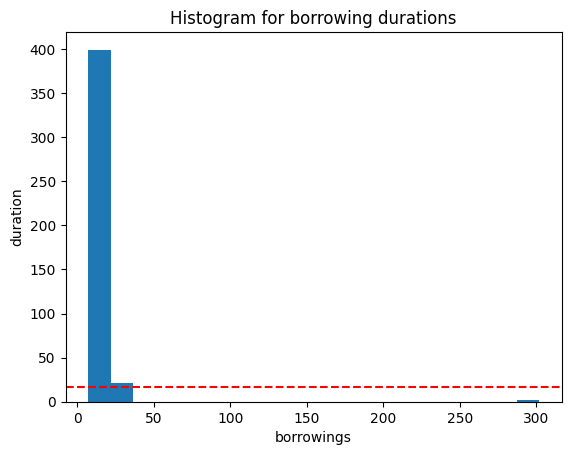

In [8]:
# Visualization EDA
import matplotlib.pyplot as plt

# visualizing the borrowing duration

plt.figure()
plt.hist(df['borrowing_duration'], bins=20)
plt.xlabel("borrowings")
plt.ylabel("duration")
plt.axhline(df['borrowing_duration'].mean(), linestyle='--', color='red')
plt.title("Histogram for borrowing durations")
plt.show()

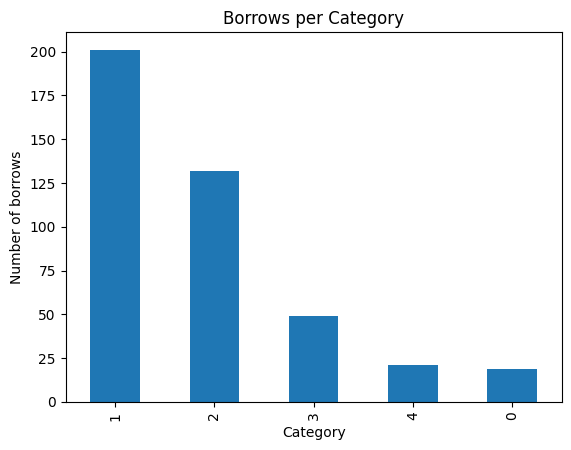

In [9]:
plt.figure()
df['category'].value_counts().plot(kind='bar')
plt.xlabel("Category")
plt.ylabel("Number of borrows")
plt.title("Borrows per Category")
plt.show()

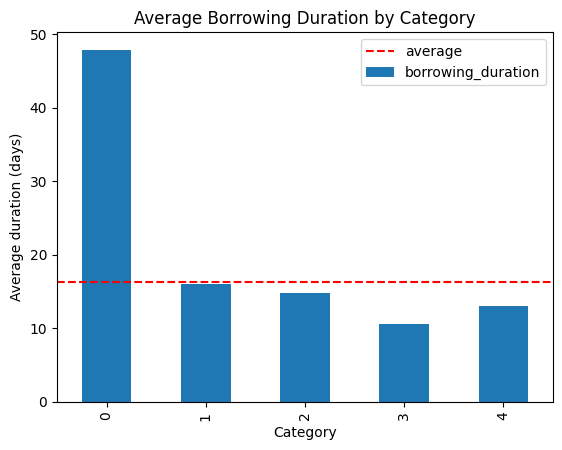

In [10]:
# visualizing the average borrowing duration per category

plt.figure()
df.groupby('category')['borrowing_duration'].mean().plot(kind='bar')
plt.xlabel("Category")
plt.ylabel("Average duration (days)")
plt.title("Average Borrowing Duration by Category")
plt.axhline(df['borrowing_duration'].mean(), linestyle='--', color='red', label='average')
plt.legend()
plt.show()

<Figure size 640x480 with 0 Axes>

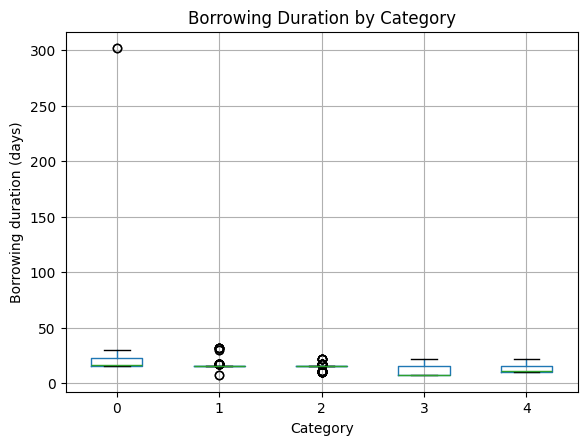

In [11]:
# boxplot (category vs borrowing_duration) for detecting outliers

plt.figure()
df.boxplot(column='borrowing_duration', by='category')
plt.xlabel("Category")
plt.ylabel("Borrowing duration (days)")
plt.title("Borrowing Duration by Category")
plt.suptitle("")
plt.show()

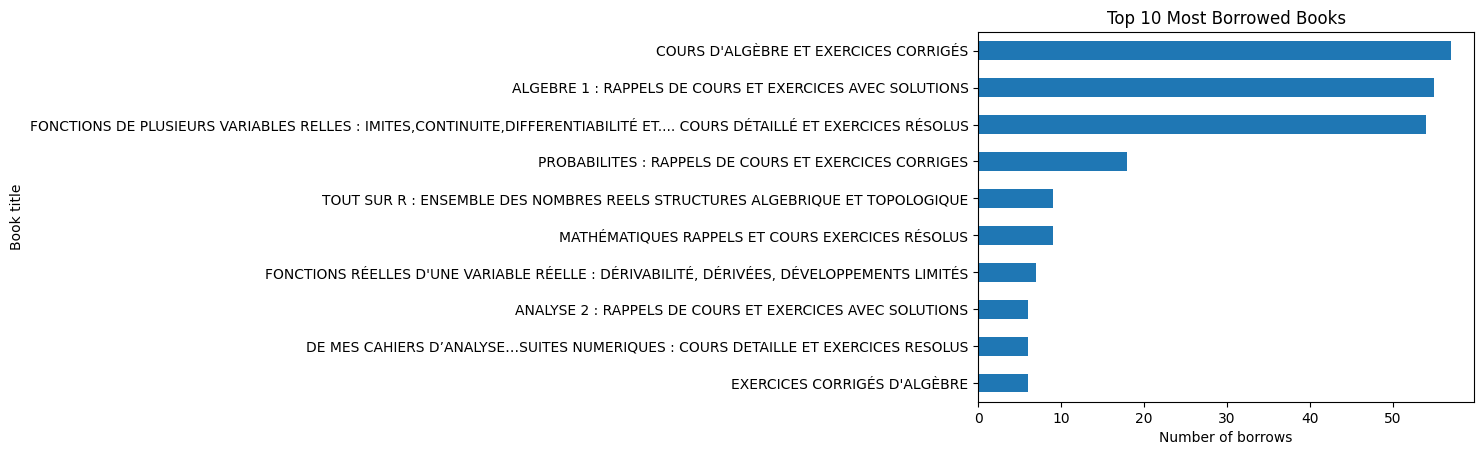

In [12]:
# most borrowed books

plt.figure()
df['Title'].value_counts().head(10).plot(kind='barh')
plt.xlabel("Number of borrows")
plt.ylabel("Book title")
plt.title("Top 10 Most Borrowed Books")
plt.gca().invert_yaxis()
plt.show()

In [14]:
MissingValueSummary(df)

Number of instances = 422

Missing Values Summary:
            Column  Missing_Values Percent_Missing
             Title               0           0.00%
        Reader_num               0           0.00%
          category               0           0.00%
borrowing_duration               0           0.00%


In [15]:
# Export to specific path
file_path = r"../../data/processed/library_borrowings.csv"  # Windows

df.to_csv(file_path, index=False, encoding='utf-8')
print(f"Data exported to: {file_path}")

Data exported to: ../../data/processed/library_borrowings.csv
